## 11.05节练习参考答案

## 环境准备

In [ ]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch
import math

from src.utils import *

本节的解答思路参考了 [《动手学深度学习》习题解答](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/ch11/ch11)。

### 练习11.5.1
修改批量大小和学习率，并观察目标函数值的下降率以及每个迭代轮数消耗的时间。

**解答：**

In [2]:
def train_sgd(lr, batch_size, num_epochs=2):
    data_iter, feature_dim = get_data_ch11(batch_size)
    return train_ch11(
        sgd, None, {'lr': lr}, data_iter, feature_dim, num_epochs)

loss: 0.243, 0.023 sec/epoch


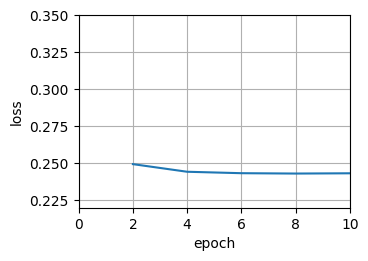

In [3]:
gd_res = train_sgd(lr=1, batch_size=1500, num_epochs=10)

loss: 0.244, 0.066 sec/epoch


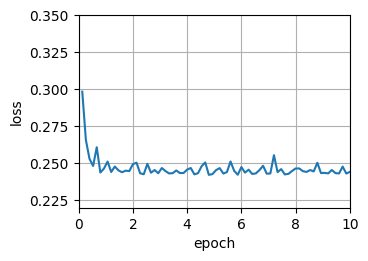

In [4]:
sgd_res = train_sgd(lr=0.005, batch_size=1, num_epochs=10)

loss: 0.246, 0.008 sec/epoch


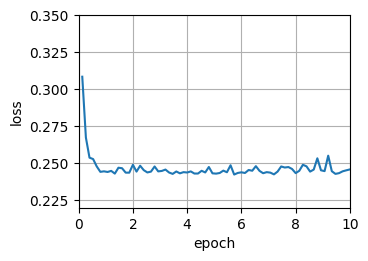

In [5]:
mini1_res = train_sgd(lr=0.05, batch_size=10 ,num_epochs=10)

loss: 0.242, 0.005 sec/epoch


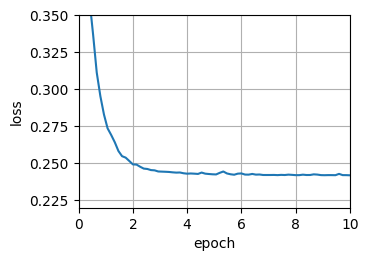

In [6]:
mini2_res = train_sgd(lr=0.05, batch_size=50 ,num_epochs=10)

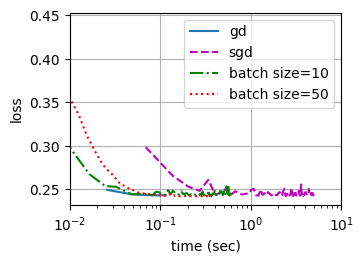

In [7]:
# 对比4种优化方式
set_figsize([6, 3])
plot(*list(map(list, zip(gd_res, sgd_res, mini1_res, mini2_res))),
         'time (sec)', 'loss', xlim=[1e-2, 10],
         legend=['gd', 'sgd', 'batch size=10', 'batch size=50'])
plt.gca().set_xscale('log')

### 练习11.5.2
将小批量随机梯度下降与实际从训练集中*取样替换*的变体进行比较。会看出什么？

**解答：**

小批量随机梯度下降（mini‑batch stochastic gradient descent）是梯度下降的一种变体，它在每次迭代中随机选择一小批训练样本来计算梯度并更新模型参数。

实际从训练集中取样替换的变体（actual sampling with replacement variant）是指每次迭代中从训练集中随机选择一个样本计算梯度并更新模型参数。

比较两者可以得出以下观察：

1. **计算效率**：小批量随机梯度下降通常比实际取样替换的变体更高效。因为小批量随机梯度下降每次迭代计算一小批样本的梯度，可以充分利用矩阵运算的并行性，加快计算速度。而实际取样替换的变体需要每次迭代计算一个样本的梯度，计算效率较低。

2. **收敛速度**：小批量随机梯度下降通常比实际取样替换的变体更快收敛。因为小批量随机梯度下降每次迭代使用多个样本的梯度更新模型参数，可以更准确地指导模型向最优解收敛。而实际取样替换的变体每次迭代只使用一个样本的梯度，可能会受到单个样本噪声的干扰，导致收敛速度较慢。

3. **模型稳定性**：小批量随机梯度下降通常比实际取样替换的变体更稳定。因为小批量随机梯度下降使用多个样本的梯度进行更新，可以减少单个样本的噪声对模型参数的影响，提高模型的稳定性。而实际取样替换的变体每次迭代只使用一个样本的梯度，容易受到噪声的干扰，导致模型参数波动较大。

综上所述，小批量随机梯度下降相对于实际取样替换的变体在计算效率、收敛速度和模型稳定性上都有优势。因此，在实际应用中，小批量随机梯度下降更常用和推荐。

### 练习11.5.3
一个邪恶的精灵在没通知你的情况下复制了你的数据集（即每个观测发生两次，数据集增加到原始大小的两倍，但没有人告诉你）。随机梯度下降、小批量随机梯度下降和梯度下降的表现将如何变化？

**解答：**

In [8]:
def get_data_ch11_duplicate(batch_size=10, n=1500):
    data = np.genfromtxt(download('airfoil'),dtype=np.float32, delimiter='\t')
    data = torch.from_numpy((data - data.mean(axis=0)) / data.std(axis=0))
    data = torch.cat((data[:n], data[:n]), dim=0)  # duplicate the data
    data_iter = load_array((data[:, :-1], data[:, -1]),batch_size, is_train=True)
    return data_iter, data.shape[1]-1

def train_sgd_duplicate(lr, batch_size, num_epochs=2):
    data_iter, feature_dim = get_data_ch11_duplicate(batch_size)
    return train_ch11(
        sgd, None, {'lr': lr}, data_iter, feature_dim, num_epochs)

loss: 0.242, 0.003 sec/epoch


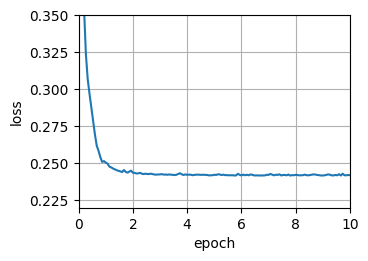

In [9]:
mini_sgd = train_sgd_duplicate(lr=0.05, batch_size=50 ,num_epochs=10)

loss: 0.291, 0.063 sec/epoch


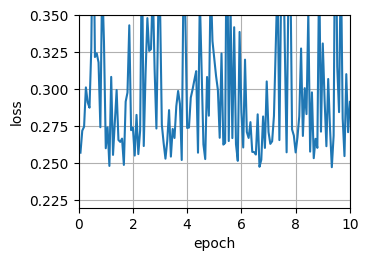

In [10]:
sgd1 = train_sgd_duplicate(lr=0.05, batch_size=1 ,num_epochs=10)

loss: 0.246, 0.062 sec/epoch


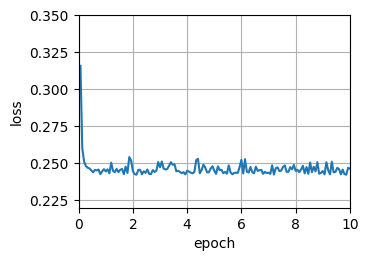

In [11]:
sgd_res = train_sgd_duplicate(lr=0.005, batch_size=1 ,num_epochs=10)


loss: 0.267, 0.023 sec/epoch


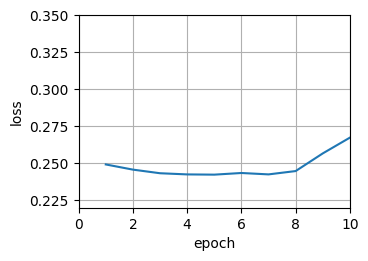

In [12]:
gd = train_sgd_duplicate(lr=1, batch_size=1500, num_epochs=10)